# M_KK constraint plots — dense scan (PDG-2024 mass + 2σ CKM gates)

This notebook regenerates the two publication figures (`fig1_exclusion_boundaries`, `fig2_mkk_bound_2007_vs_modern`) from the new dense scan whose acceptance gate uses:

- PDG-2024 MS̄ quark masses RG-evolved to μ = m_t(m_t) = 163.5 GeV (per-quark 2σ tolerances, 0.3 % numerical floor)
- PDG-2024 CKM observables with corrected per-element 2σ tolerances `[|V_us| 0.0044, |V_cb| 0.072, |V_ub| 0.10, J 0.085]`
- The KK-gluon ΔF=2 budgets unchanged from prior scans

Run dir: `scan_outputs/dense_20260506T141321/`.

In [1]:
from __future__ import annotations
import json
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from scripts.plot_publication_figures import (
    _load_results,
    _extract_arrays,
    _apply_publication_convention,
    build_exclusion_boundaries_figure,
    build_mkk_bound_comparison_figure,
    DEFAULT_PUBLICATION_XI_KK,
)

RUN_DIR = REPO_ROOT / 'scan_outputs' / 'dense_20260506T141321'
RESULTS_PATH = RUN_DIR / 'merged' / 'results.jsonl'
FIG_OUTPUT_DIR = REPO_ROOT / 'results' / 'figures' / 'quark'
FIG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('results :', RESULTS_PATH, '(exists?', RESULTS_PATH.exists(), ')')
print('outputs :', FIG_OUTPUT_DIR)

results : /n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing/scan_outputs/dense_20260506T141321/merged/results.jsonl (exists? True )
outputs : /n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing/results/figures/quark


## Load the merged JSONL and extract arrays

In [2]:
records = _load_results(RESULTS_PATH)
raw = _extract_arrays(records)
data = _apply_publication_convention(raw, xi_kk=DEFAULT_PUBLICATION_XI_KK)

n_total = len(records)
n_converged = len(raw['accepted'])
n_accepted_raw = int(raw['accepted'].sum())
n_accepted_pub = int(np.asarray(data['accepted']).sum())
print(f'records (total scanned)            : {n_total:>7}')
print(f'converged + fit_score <= 0.1       : {n_converged:>7}')
print(f'accepted (raw, ratio <= 1)         : {n_accepted_raw:>7}')
print(f'accepted (publication ξ_KK rescaled): {n_accepted_pub:>7}')
print(f'\npublication ξ_KK = {DEFAULT_PUBLICATION_XI_KK:.4f}')
print(f'data["r"] range : {float(data["r"].min()):.3f} … {float(data["r"].max()):.3f}')
print(f'data["M_KK"] range : {float(data["M_KK"].min()):.0f} … {float(data["M_KK"].max()):.0f} GeV')

records (total scanned)            :  100000
converged + fit_score <= 0.1       :   99997
accepted (raw, ratio <= 1)         :   62703
accepted (publication ξ_KK rescaled):   83961

publication ξ_KK = 2.4487
data["r"] range : 0.020 … 2.000
data["M_KK"] range : 1224 … 48974 GeV


## Figure 1: per-system exclusion boundaries in (r, M_KK)

Each contour shows the boundary at which one ΔF=2 system (ε_K, ΔM_K, ΔM_{B_d}, ΔM_{B_s}, ΔM_{D⁰}) saturates its budget. Below the contour the model is excluded by that system; above it the model is allowed. The publication convention rescales the propagator to the physical first KK-gluon mass m_g^{(1)} = ξ_KK · Λ_IR with ξ_KK ≈ 2.4487.

saved /n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing/results/figures/quark/fig1_exclusion_boundaries_pdg2024.pdf
saved /n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing/results/figures/quark/fig1_exclusion_boundaries_pdg2024.png


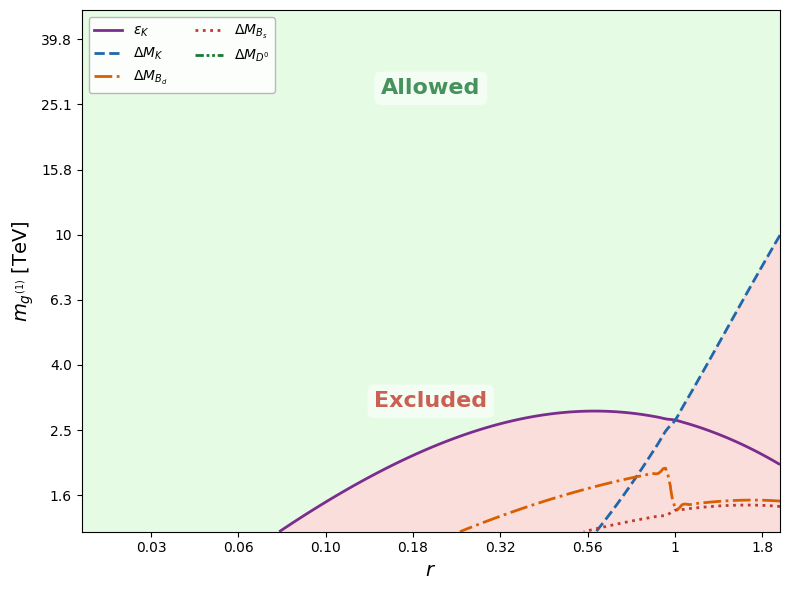

In [3]:
fig1 = build_exclusion_boundaries_figure(data)
if fig1 is None:
    print('insufficient grid points for fig1 — skipping')
else:
    out_pdf = FIG_OUTPUT_DIR / 'fig1_exclusion_boundaries_pdg2024.pdf'
    out_png = FIG_OUTPUT_DIR / 'fig1_exclusion_boundaries_pdg2024.png'
    fig1.savefig(out_pdf, bbox_inches='tight')
    fig1.savefig(out_png, bbox_inches='tight', dpi=200)
    print('saved', out_pdf)
    print('saved', out_png)
    plt.show()

## Figure 2: M_KK lower bound — 2007 vs modern

For each value of r, this figure shows the lowest M_KK at which any scanned point satisfies *all five* ΔF=2 systems simultaneously. The 2007 curve uses the budgets from Agashe-Contino-Pomarol (hep-ph/0412089 era); the modern curve uses present-day FLAG/PDG hadronic inputs and the KK-gluon coefficient ratios `BOUND_RATIOS` defined in the publication script. A modern bound below the 2007 bound at the same r means hadronic precision has tightened the exclusion.

saved /n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing/results/figures/quark/fig2_mkk_bound_2007_vs_modern_pdg2024.pdf
saved /n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing/results/figures/quark/fig2_mkk_bound_2007_vs_modern_pdg2024.png


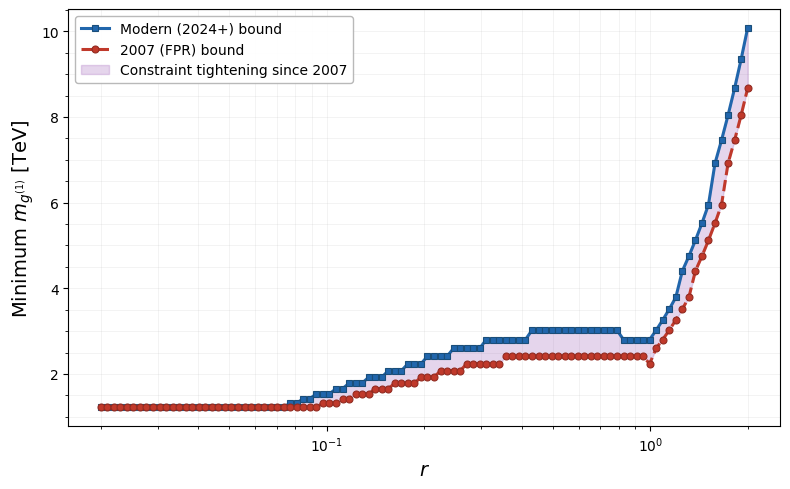

In [4]:
fig2 = build_mkk_bound_comparison_figure(data)
out_pdf = FIG_OUTPUT_DIR / 'fig2_mkk_bound_2007_vs_modern_pdg2024.pdf'
out_png = FIG_OUTPUT_DIR / 'fig2_mkk_bound_2007_vs_modern_pdg2024.png'
fig2.savefig(out_pdf, bbox_inches='tight')
fig2.savefig(out_png, bbox_inches='tight', dpi=200)
print('saved', out_pdf)
print('saved', out_png)
plt.show()

## Per-system rejection breakdown

Among rejected points, which ΔF=2 system is most often the binding constraint?

In [5]:
from collections import Counter
rejected_failing = [tuple(sorted(f)) for f, a in zip(raw['failing'], raw['accepted']) if not a]
system_counts = Counter()
for failing in rejected_failing:
    for s in failing:
        system_counts[s] += 1

n_rej = len(rejected_failing)
print(f'rejected points (after fit-quality filter): {n_rej:,}')
print(f'(of {n_converged:,} converged-with-good-fit points)\n')
print('Number of rejected points where each system was a failing constraint:')
for s, c in system_counts.most_common():
    pct = 100 * c / max(n_rej, 1)
    print(f'  {s:<12} {c:>6} ({pct:5.1f} %)')

rejected points (after fit-quality filter): 37,294
(of 99,997 converged-with-good-fit points)

Number of rejected points where each system was a failing constraint:
  epsilon_K     34096 ( 91.4 %)
  B_d           17936 ( 48.1 %)
  K             15880 ( 42.6 %)
  B_s           15012 ( 40.3 %)
  D0             4507 ( 12.1 %)


## Saved outputs

- `results/figures/quark/fig1_exclusion_boundaries_pdg2024.{pdf,png}`
- `results/figures/quark/fig2_mkk_bound_2007_vs_modern_pdg2024.{pdf,png}`

These are placed alongside the legacy `fig1_exclusion_boundaries.png` and `fig2_mkk_bound_2007_vs_modern.png` so the two epochs can be diffed visually.